# Classificação de Grãos de Trigo com Machine Learning (CRISP-DM)

**Objetivo:** aplicar a metodologia CRISP-DM para classificar variedades de grãos de trigo com base em características físicas.

Este notebook foi estruturado como um gabarito/base de estudo, cobrindo:

1. Entendimento e preparação dos dados;
2. Análise exploratória com estatísticas e gráficos;
3. Treinamento e comparação de modelos de classificação;
4. Otimização com Grid Search;
5. Interpretação dos resultados e insights.

**Dataset:** Seeds Dataset — UCI Machine Learning Repository.

**Classes:**
- 1 = Kama
- 2 = Rosa
- 3 = Canadian


In [5]:
%pip install seaborn
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install sklearn


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

## 1. Importação das bibliotecas

Aqui importamos as bibliotecas necessárias para leitura dos dados, análise exploratória, visualização, pré-processamento, treinamento, avaliação e otimização dos modelos.


In [6]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão dos dados
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de classificação
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

# Para garantir reprodutibilidade
RANDOM_STATE = 42


## 2. Carregamento do dataset

O arquivo `seeds_dataset.txt` possui 8 colunas: 7 características físicas do grão e 1 coluna alvo com a variedade do trigo.

Como o arquivo original não vem com cabeçalho, vamos nomear as colunas manualmente.


In [7]:
# Caminho do arquivo
# Se estiver no Google Colab, faça upload do arquivo e ajuste o caminho para '/content/seeds_dataset.txt'
# Se estiver localmente, deixe o arquivo na mesma pasta do notebook ou ajuste o caminho abaixo.

caminho_arquivo = 'seeds_dataset.txt'

colunas = [
    'area',
    'perimetro',
    'compacidade',
    'comprimento_nucleo',
    'largura_nucleo',
    'coef_assimetria',
    'comprimento_sulco',
    'classe'
]

try:
    df = pd.read_csv(caminho_arquivo, sep=r'\s+', header=None, names=colunas)
except FileNotFoundError:
    # Caminho usado neste gabarito quando executado no ambiente do ChatGPT
    caminho_arquivo = '/mnt/data/seeds_dataset.txt'
    df = pd.read_csv(caminho_arquivo, sep=r'\s+', header=None, names=colunas)

# Mapeamento das classes para nomes das variedades
mapa_classes = {
    1: 'Kama',
    2: 'Rosa',
    3: 'Canadian'
}

df['variedade'] = df['classe'].map(mapa_classes)

# Exibe as primeiras linhas
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/seeds_dataset.txt'

## 3. Entendimento inicial dos dados

Nesta etapa, verificamos quantidade de linhas e colunas, tipos de dados, valores ausentes e distribuição das classes.


In [ ]:
print('Dimensão da base:', df.shape)
print('Tipos de dados:')
print(df.dtypes)

print('Valores ausentes por coluna:')
print(df.isnull().sum())

print('Quantidade por classe:')
print(df['variedade'].value_counts())


Dimensão da base: (210, 9)
Tipos de dados:
area                  float64
perimetro             float64
compacidade           float64
comprimento_nucleo    float64
largura_nucleo        float64
coef_assimetria       float64
comprimento_sulco     float64
classe                  int64
variedade              object
dtype: object
Valores ausentes por coluna:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
classe                0
variedade             0
dtype: int64
Quantidade por classe:
variedade
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


### Observação inicial

A base possui 210 amostras e 3 classes. Como as classes possuem a mesma quantidade de registros, temos uma base balanceada. Isso é positivo, pois a acurácia tende a ser uma métrica mais confiável quando não existe forte desbalanceamento entre as classes.


## 4. Estatísticas descritivas

A atividade solicita média, mediana e desvio padrão para cada característica. Também vamos usar o `describe()` para ter uma visão geral dos valores mínimos, máximos e quartis.


In [ ]:
features = [
    'area',
    'perimetro',
    'compacidade',
    'comprimento_nucleo',
    'largura_nucleo',
    'coef_assimetria',
    'comprimento_sulco'
]

estatisticas = pd.DataFrame({
    'media': df[features].mean(),
    'mediana': df[features].median(),
    'desvio_padrao': df[features].std(),
    'minimo': df[features].min(),
    'maximo': df[features].max()
})

estatisticas


,media,mediana,desvio_padrao,minimo,maximo
area,14.847524,14.35500,2.909699,10.5900,21.1800
perimetro,14.559286,14.32000,1.305959,12.4100,17.2500
compacidade,0.870999,0.87345,0.023629,0.8081,0.9183
comprimento_nucleo,5.628533,5.52350,0.443063,4.8990,6.6750
largura_nucleo,3.258605,3.23700,0.377714,2.6300,4.0330
coef_assimetria,3.700201,3.59900,1.503557,0.7651,8.4560
comprimento_sulco,5.408071,5.22300,0.491480,4.5190,6.5500


In [ ]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
perimetro,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
compacidade,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
comprimento_nucleo,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
largura_nucleo,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
coef_assimetria,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
comprimento_sulco,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500


## 5. Distribuição das classes

Antes dos modelos, é importante visualizar se existe equilíbrio entre as variedades.


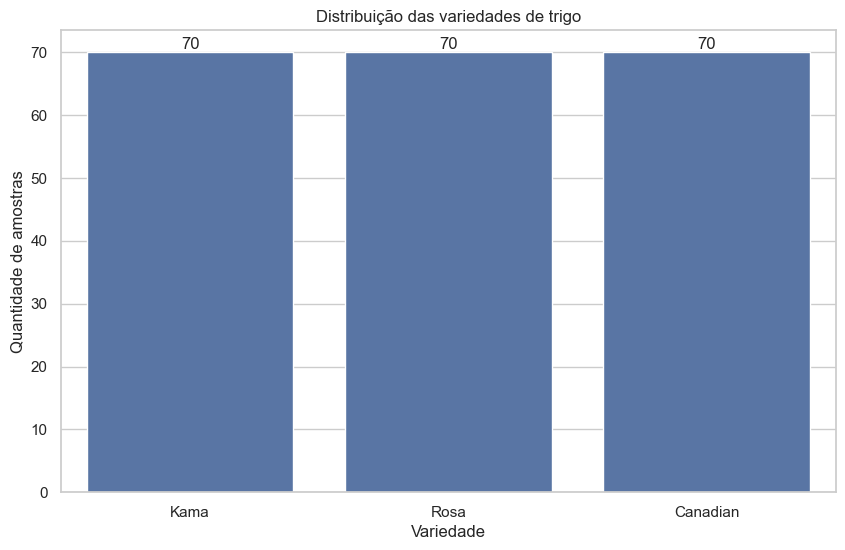

In [ ]:
ax = sns.countplot(data=df, x='variedade')
plt.title('Distribuição das variedades de trigo')
plt.xlabel('Variedade')
plt.ylabel('Quantidade de amostras')

for container in ax.containers:
    ax.bar_label(container)

plt.show()


## 6. Histogramas das características

Os histogramas ajudam a entender a distribuição dos dados de cada variável. Em alguns casos, é possível observar diferenças de concentração entre as variedades.


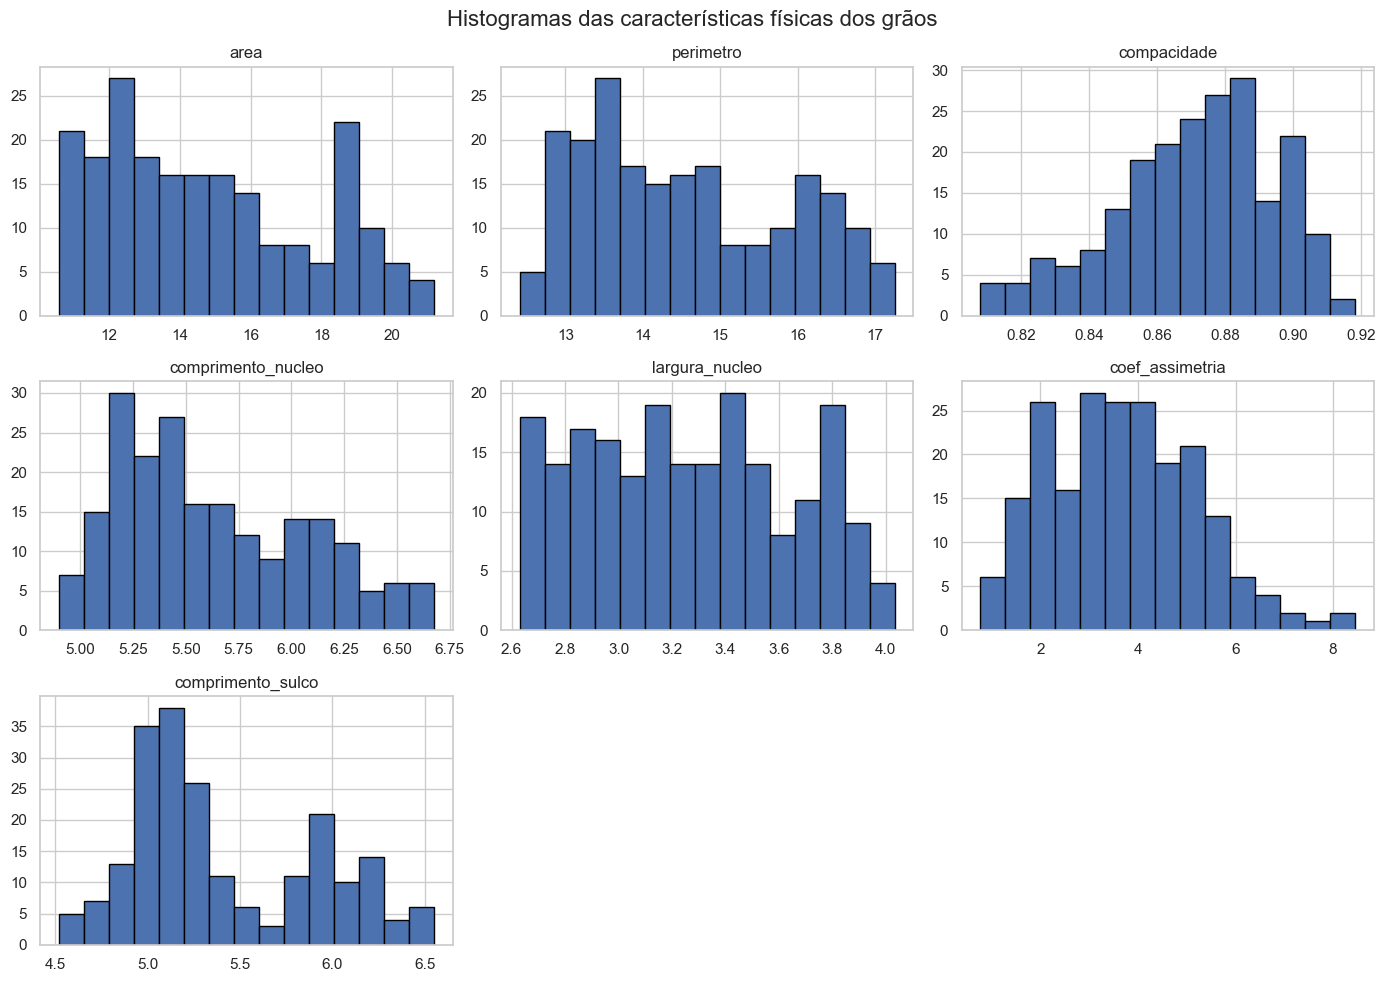

In [ ]:
df[features].hist(bins=15, figsize=(14, 10), edgecolor='black')
plt.suptitle('Histogramas das características físicas dos grãos', fontsize=16)
plt.tight_layout()
plt.show()


## 7. Boxplots por variedade

Os boxplots ajudam a comparar cada característica entre as variedades Kama, Rosa e Canadian, além de evidenciar possíveis valores extremos.


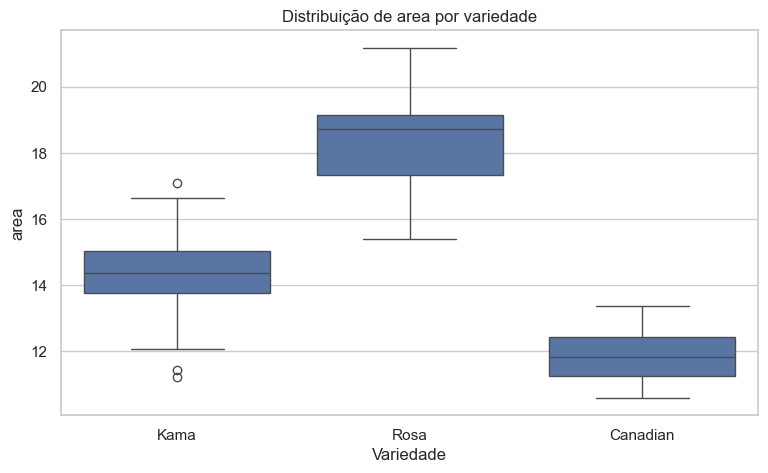

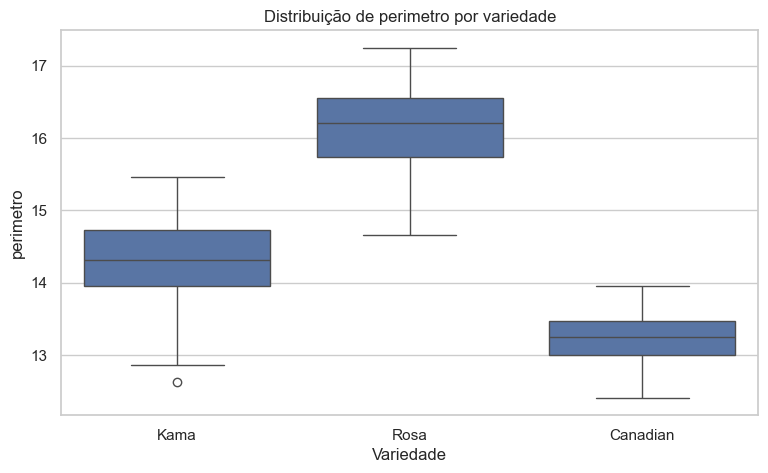

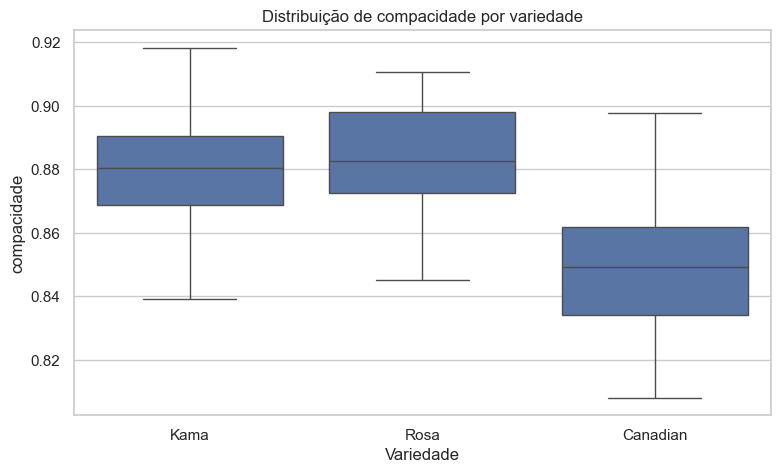

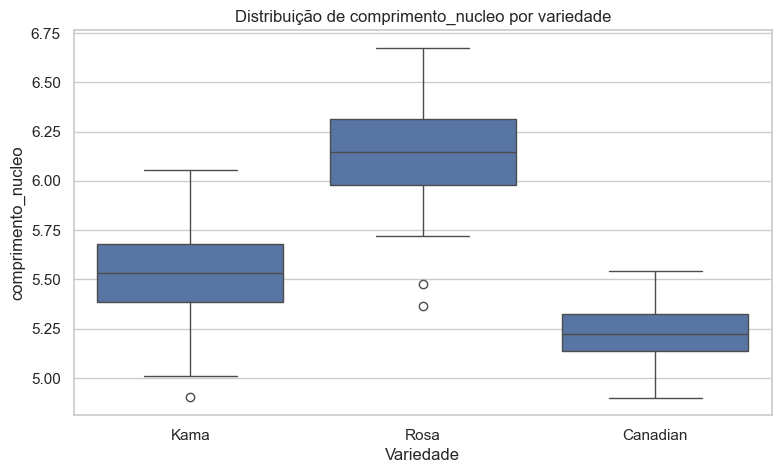

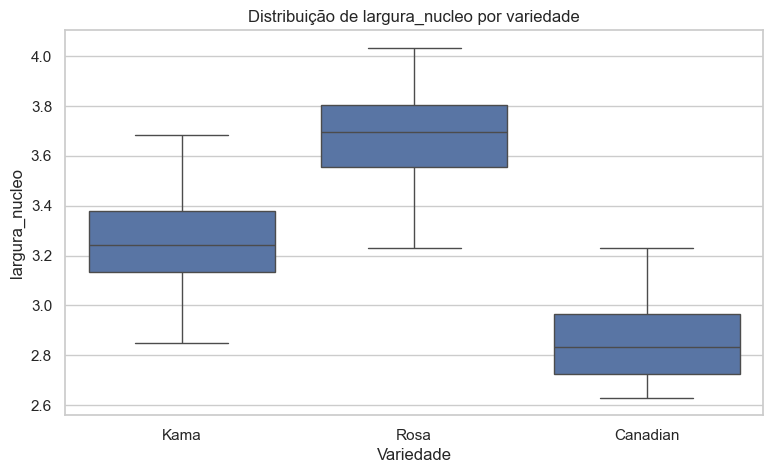

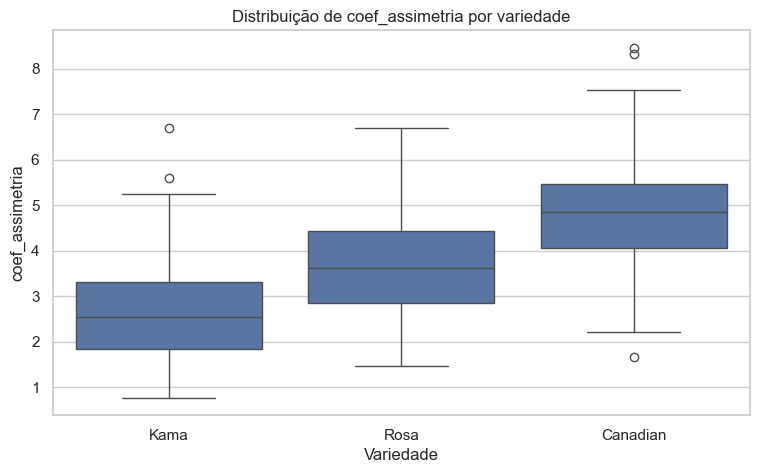

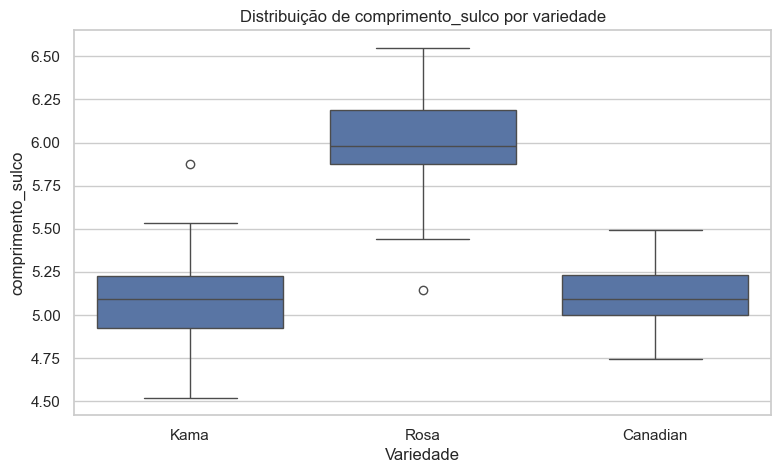

In [ ]:
for coluna in features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x='variedade', y=coluna)
    plt.title(f'Distribuição de {coluna} por variedade')
    plt.xlabel('Variedade')
    plt.ylabel(coluna)
    plt.show()


## 8. Correlação entre as características

A matriz de correlação ajuda a identificar quais variáveis estão mais relacionadas. Valores próximos de 1 indicam forte relação positiva; valores próximos de -1 indicam forte relação negativa.


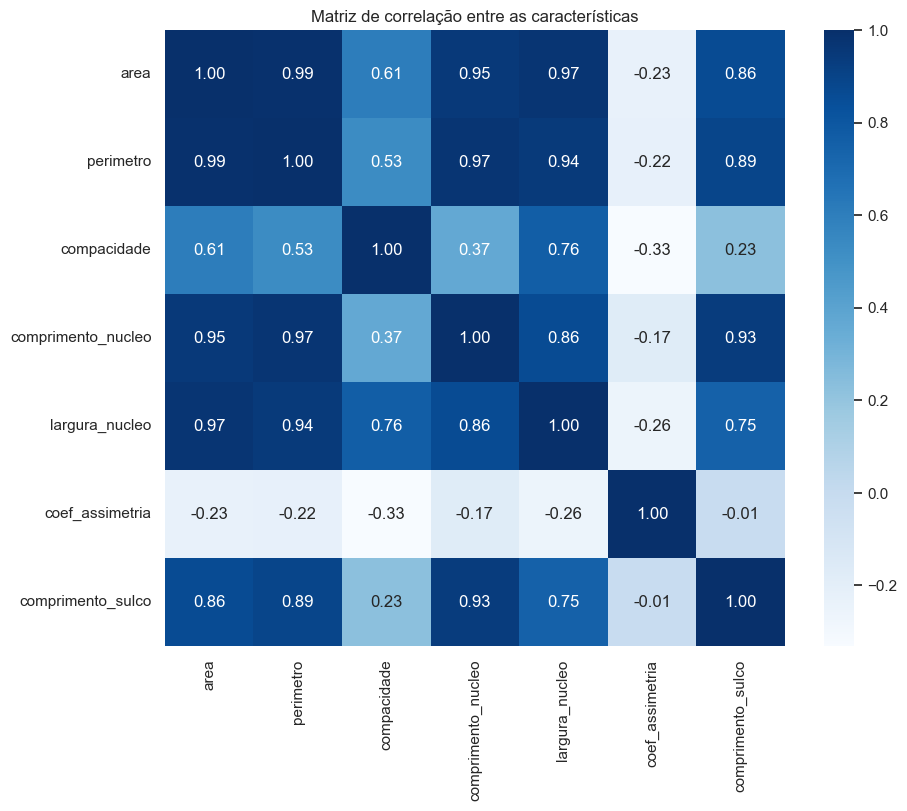

In [ ]:
correlacao = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de correlação entre as características')
plt.show()


### Análise da correlação

De forma geral, variáveis como **área**, **perímetro**, **comprimento do núcleo** e **largura do núcleo** tendem a apresentar correlações fortes entre si. Isso faz sentido no contexto físico: grãos maiores costumam apresentar maior área, maior perímetro e maiores medidas de comprimento/largura.

Já o **coeficiente de assimetria** costuma apresentar uma relação mais fraca com as demais variáveis, indicando que ele pode trazer uma informação diferente sobre o formato do grão.


## 9. Gráficos de dispersão

Os gráficos de dispersão ajudam a visualizar se as classes formam grupos separados quando analisamos duas variáveis ao mesmo tempo.


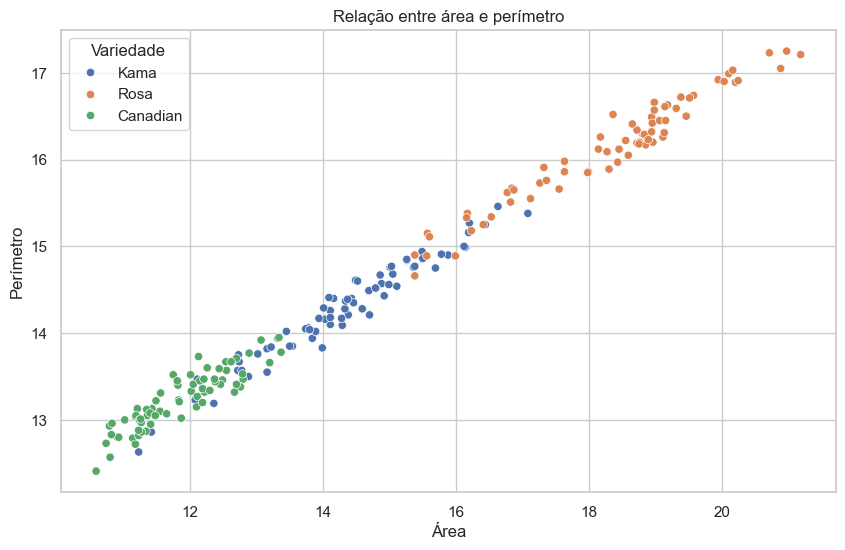

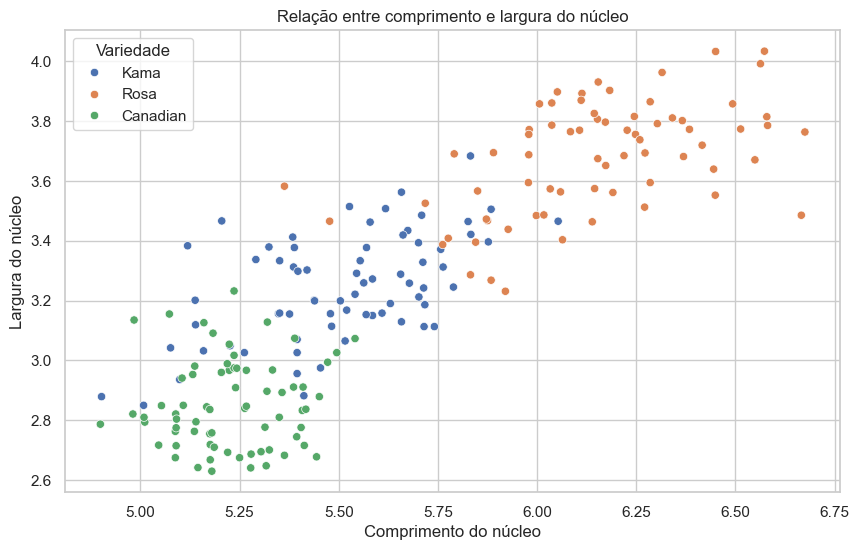

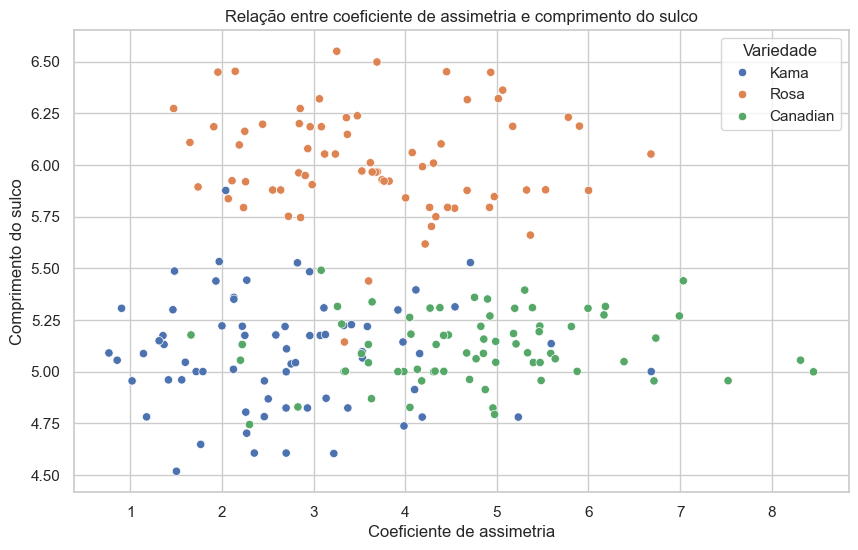

In [ ]:
sns.scatterplot(data=df, x='area', y='perimetro', hue='variedade')
plt.title('Relação entre área e perímetro')
plt.xlabel('Área')
plt.ylabel('Perímetro')
plt.legend(title='Variedade')
plt.show()

sns.scatterplot(data=df, x='comprimento_nucleo', y='largura_nucleo', hue='variedade')
plt.title('Relação entre comprimento e largura do núcleo')
plt.xlabel('Comprimento do núcleo')
plt.ylabel('Largura do núcleo')
plt.legend(title='Variedade')
plt.show()

sns.scatterplot(data=df, x='coef_assimetria', y='comprimento_sulco', hue='variedade')
plt.title('Relação entre coeficiente de assimetria e comprimento do sulco')
plt.xlabel('Coeficiente de assimetria')
plt.ylabel('Comprimento do sulco')
plt.legend(title='Variedade')
plt.show()


## 10. Pairplot das principais variáveis

O pairplot permite observar várias relações ao mesmo tempo. Para não deixar o gráfico pesado, vamos selecionar algumas características mais relevantes.


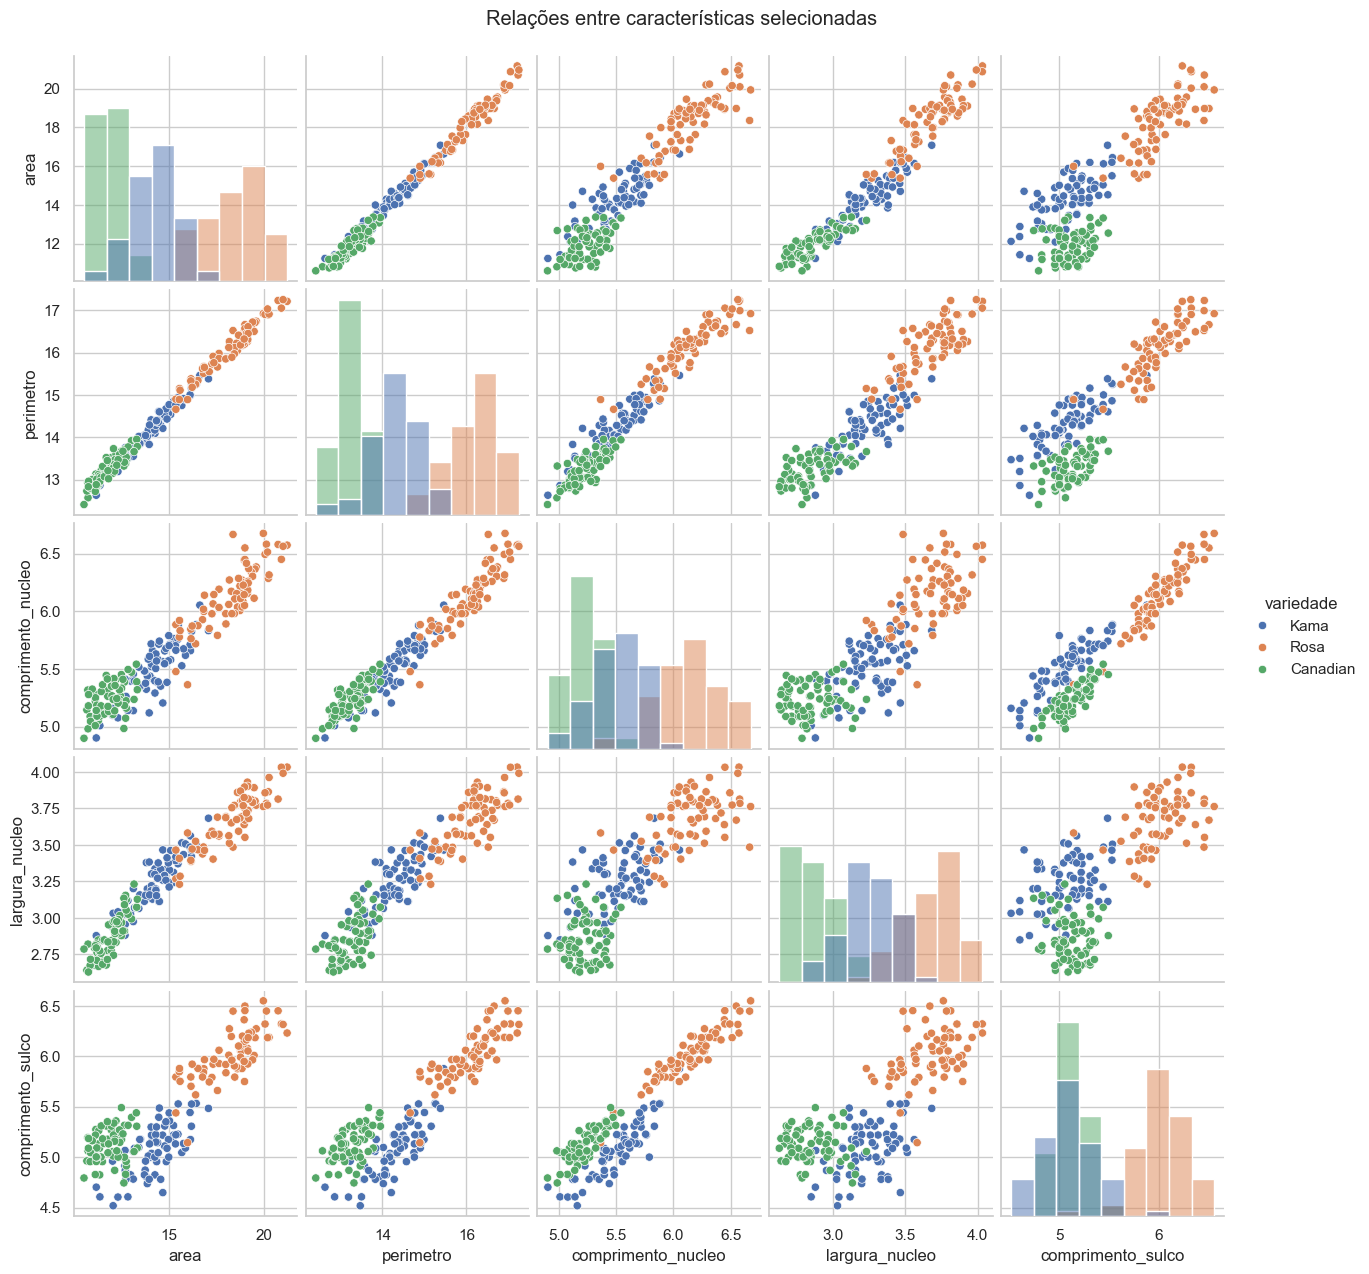

In [ ]:
variaveis_pairplot = [
    'area',
    'perimetro',
    'comprimento_nucleo',
    'largura_nucleo',
    'comprimento_sulco',
    'variedade'
]

sns.pairplot(df[variaveis_pairplot], hue='variedade', diag_kind='hist')
plt.suptitle('Relações entre características selecionadas', y=1.02)
plt.show()


## 11. Tratamento de valores ausentes

A atividade solicita identificar e tratar valores ausentes. Nesta base, a verificação indica que não existem valores ausentes. Mesmo assim, deixamos uma estrutura de tratamento caso futuramente a base venha com dados faltantes.


In [ ]:
print('Valores ausentes antes do tratamento:')
print(df[features + ['classe']].isnull().sum())

# Caso existissem valores ausentes, uma alternativa simples seria preencher com a mediana:
df_tratado = df.copy()
df_tratado[features] = df_tratado[features].fillna(df_tratado[features].median())

print('Valores ausentes depois do tratamento:')
print(df_tratado[features + ['classe']].isnull().sum())


Valores ausentes antes do tratamento:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
classe                0
dtype: int64
Valores ausentes depois do tratamento:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
classe                0
dtype: int64


## 12. Separação entre variáveis explicativas e alvo

As variáveis explicativas (`X`) são as características físicas dos grãos. A variável alvo (`y`) é a classe da variedade de trigo.


In [ ]:
X = df_tratado[features]
y = df_tratado['classe']

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)


Formato de X: (210, 7)
Formato de y: (210,)


## 13. Separação entre treino e teste

Vamos separar 70% dos dados para treinamento e 30% para teste. O parâmetro `stratify=y` mantém a mesma proporção das classes nos conjuntos de treino e teste.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Treino:', X_train.shape, y_train.shape)
print('Teste:', X_test.shape, y_test.shape)

print('Distribuição no treino:')
print(y_train.value_counts().sort_index())

print('Distribuição no teste:')
print(y_test.value_counts().sort_index())


Treino: (147, 7) (147,)
Teste: (63, 7) (63,)
Distribuição no treino:
classe
1    49
2    49
3    49
Name: count, dtype: int64
Distribuição no teste:
classe
1    21
2    21
3    21
Name: count, dtype: int64


## 14. Avaliação da necessidade de escala

Algoritmos baseados em distância ou margem, como **KNN**, **SVM** e **Regressão Logística**, são sensíveis à escala das variáveis. Como as características possuem unidades e amplitudes diferentes, vamos usar **StandardScaler** dentro de um `Pipeline`.

O **Random Forest** e o **Naive Bayes** não dependem tanto da escala, mas o uso de pipeline ajuda a manter o processo organizado.


## 15. Treinamento e comparação dos modelos

Vamos treinar cinco algoritmos de classificação:

- KNN;
- SVM;
- Random Forest;
- Naive Bayes;
- Logistic Regression.

Para comparação, serão usadas as métricas: acurácia, precisão, recall e F1-score.


In [ ]:
modelos = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', KNeighborsClassifier())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', SVC(random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('modelo', RandomForestClassifier(random_state=RANDOM_STATE))
    ]),
    'Naive Bayes': Pipeline([
        ('modelo', GaussianNB())
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])
}

resultados = []
predicoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    predicoes[nome] = y_pred

    resultados.append({
        'modelo': nome,
        'acuracia': accuracy_score(y_test, y_pred),
        'precisao_weighted': precision_score(y_test, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_test, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted')
    })

resultado_modelos = pd.DataFrame(resultados).sort_values(by='f1_weighted', ascending=False)
resultado_modelos


,modelo,acuracia,precisao_weighted,recall_weighted,f1_weighted
2,Random Forest,0.920635,0.923942,0.920635,0.919170
0,KNN,0.873016,0.872144,0.873016,0.871284
1,SVM,0.873016,0.872144,0.873016,0.871284
4,Logistic Regression,0.857143,0.857143,0.857143,0.854294
3,Naive Bayes,0.825397,0.833928,0.825397,0.825060


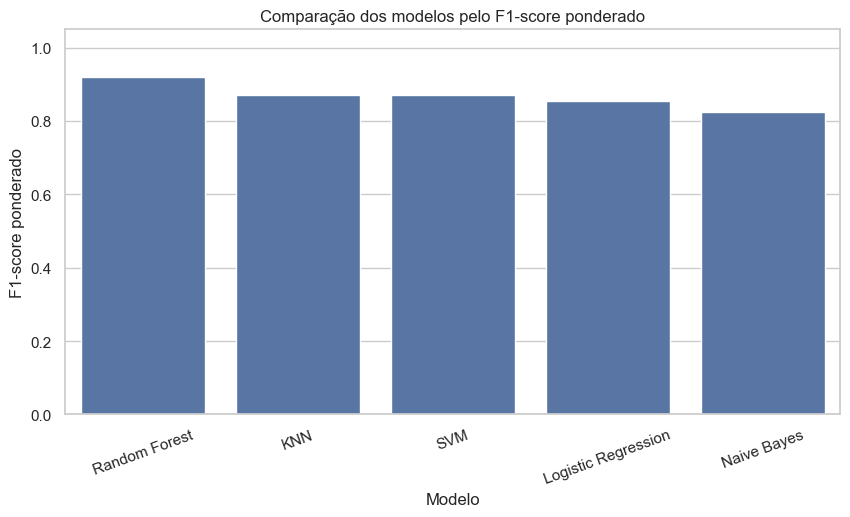

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=resultado_modelos, x='modelo', y='f1_weighted')
plt.title('Comparação dos modelos pelo F1-score ponderado')
plt.xlabel('Modelo')
plt.ylabel('F1-score ponderado')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()


## 16. Relatórios de classificação

Agora vamos analisar o desempenho por classe, observando precisão, recall e F1-score para Kama, Rosa e Canadian.


In [ ]:
nomes_classes = ['Kama', 'Rosa', 'Canadian']

for nome, y_pred in predicoes.items():
    print('=' * 80)
    print(f'Modelo: {nome}')
    print(classification_report(y_test, y_pred, target_names=nomes_classes))


Modelo: KNN
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Modelo: SVM
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Modelo: Random Forest
              precision    recall  f1-score   support

        Kama       0.94      0.81      0.87        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.88      

## 17. Matrizes de confusão

A matriz de confusão mostra onde o modelo acertou e onde confundiu uma variedade com outra. A diagonal principal representa os acertos.


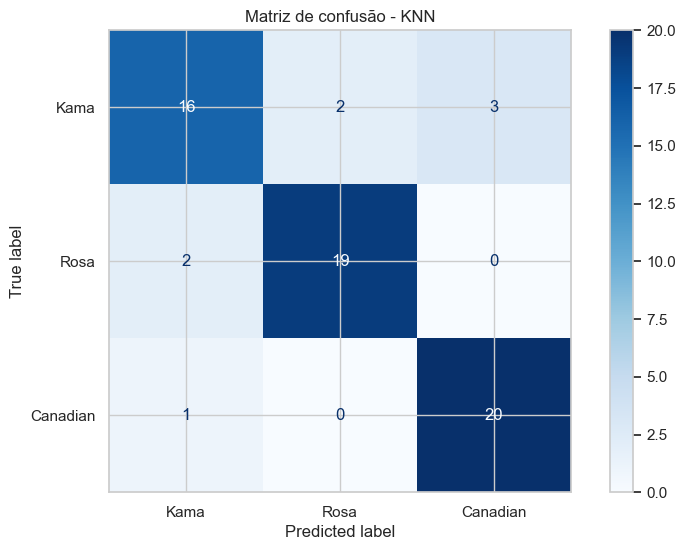

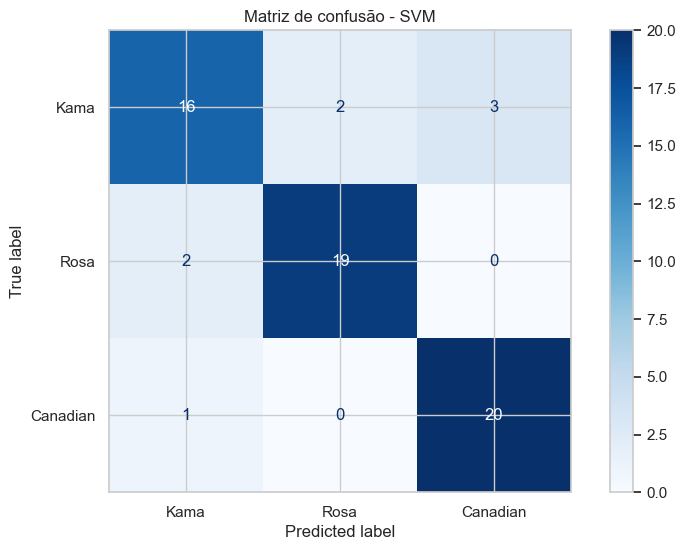

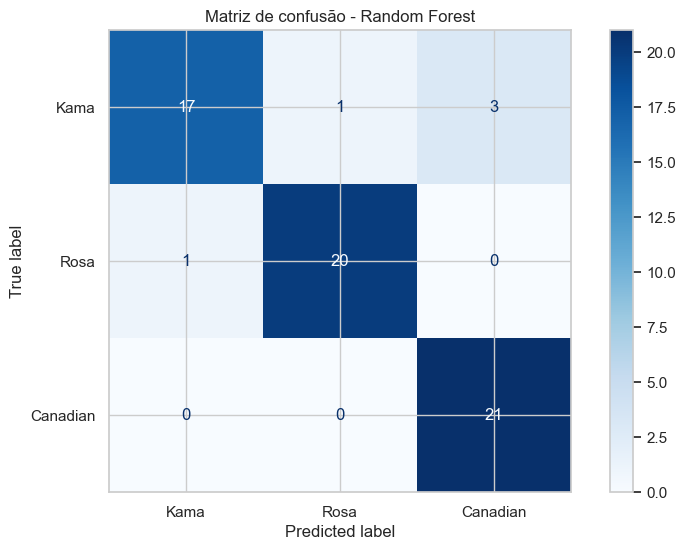

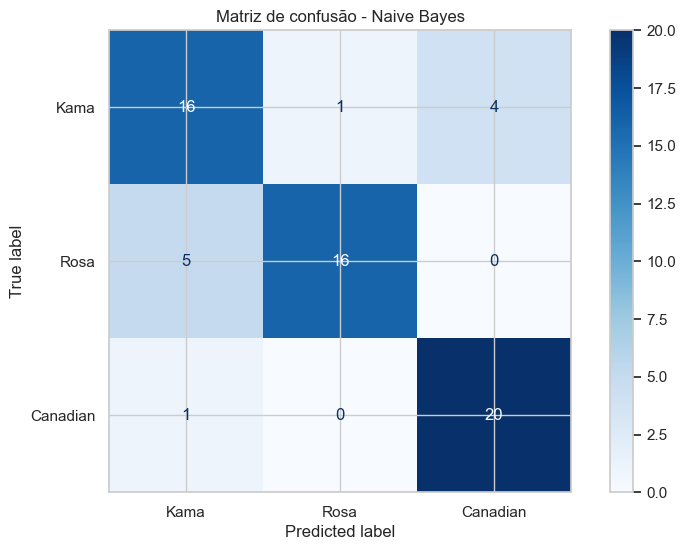

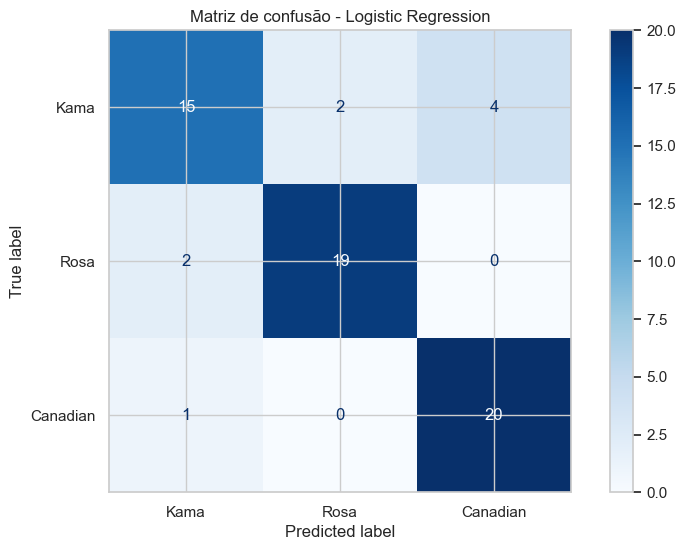

In [ ]:
for nome, y_pred in predicoes.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de confusão - {nome}')
    plt.show()


## 18. Otimização dos modelos com Grid Search

Após a avaliação inicial, vamos otimizar alguns modelos. A ideia é testar combinações de hiperparâmetros e selecionar aquelas que geram melhor desempenho em validação cruzada.

Serão otimizados:
- KNN;
- SVM;
- Random Forest;
- Logistic Regression.

O Naive Bayes foi mantido sem otimização relevante neste exemplo por possuir poucos hiperparâmetros principais para este tipo de aplicação.


In [ ]:
param_grids = {
    'KNN': {
        'modelo__n_neighbors': [3, 5, 7, 9, 11],
        'modelo__weights': ['uniform', 'distance'],
        'modelo__metric': ['euclidean', 'manhattan']
    },
    'SVM': {
        'modelo__C': [0.1, 1, 10, 100],
        'modelo__kernel': ['linear', 'rbf'],
        'modelo__gamma': ['scale', 'auto']
    },
    'Random Forest': {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [None, 3, 5, 10],
        'modelo__min_samples_split': [2, 4, 6]
    },
    'Logistic Regression': {
        'modelo__C': [0.01, 0.1, 1, 10, 100],
        'modelo__solver': ['lbfgs']
    }
}

modelos_para_otimizar = {
    'KNN': modelos['KNN'],
    'SVM': modelos['SVM'],
    'Random Forest': modelos['Random Forest'],
    'Logistic Regression': modelos['Logistic Regression']
}

melhores_modelos = {}
resultados_otimizados = []

for nome, modelo in modelos_para_otimizar.items():
    print(f'Otimizando {nome}...')
    grid = GridSearchCV(
        estimator=modelo,
        param_grid=param_grids[nome],
        scoring='f1_weighted',
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    melhores_modelos[nome] = grid.best_estimator_

    y_pred_otimizado = grid.predict(X_test)

    resultados_otimizados.append({
        'modelo': nome,
        'melhor_f1_cv': grid.best_score_,
        'acuracia_teste': accuracy_score(y_test, y_pred_otimizado),
        'precisao_teste': precision_score(y_test, y_pred_otimizado, average='weighted'),
        'recall_teste': recall_score(y_test, y_pred_otimizado, average='weighted'),
        'f1_teste': f1_score(y_test, y_pred_otimizado, average='weighted'),
        'melhores_parametros': grid.best_params_
    })

resultado_otimizado = pd.DataFrame(resultados_otimizados).sort_values(by='f1_teste', ascending=False)
resultado_otimizado


Otimizando KNN...
Otimizando SVM...
Otimizando Random Forest...
Otimizando Logistic Regression...


,modelo,melhor_f1_cv,acuracia_teste,precisao_teste,recall_teste,f1_teste,melhores_parametros
2,Random Forest,0.905662,0.920635,0.923942,0.920635,0.919170,"{'modelo__max_depth': None, 'modelo__min_sampl..."
0,KNN,0.945612,0.888889,0.887951,0.888889,0.888088,"{'modelo__metric': 'manhattan', 'modelo__n_nei..."
1,SVM,0.973087,0.888889,0.890789,0.888889,0.887534,"{'modelo__C': 100, 'modelo__gamma': 'scale', '..."
3,Logistic Regression,0.972856,0.888889,0.890789,0.888889,0.887534,"{'modelo__C': 100, 'modelo__solver': 'lbfgs'}"


## 19. Comparação antes e depois da otimização

Agora vamos comparar os resultados dos modelos antes e depois da otimização.


In [ ]:
comparacao = resultado_modelos[['modelo', 'acuracia', 'f1_weighted']].rename(columns={
    'acuracia': 'acuracia_inicial',
    'f1_weighted': 'f1_inicial'
})

comparacao_otimizada = resultado_otimizado[['modelo', 'acuracia_teste', 'f1_teste']].rename(columns={
    'acuracia_teste': 'acuracia_otimizada',
    'f1_teste': 'f1_otimizado'
})

comparacao_final = comparacao.merge(comparacao_otimizada, on='modelo', how='left')
comparacao_final


,modelo,acuracia_inicial,f1_inicial,acuracia_otimizada,f1_otimizado
0,Random Forest,0.920635,0.919170,0.920635,0.919170
1,KNN,0.873016,0.871284,0.888889,0.888088
2,SVM,0.873016,0.871284,0.888889,0.887534
3,Logistic Regression,0.857143,0.854294,0.888889,0.887534
4,Naive Bayes,0.825397,0.825060,NaN,NaN


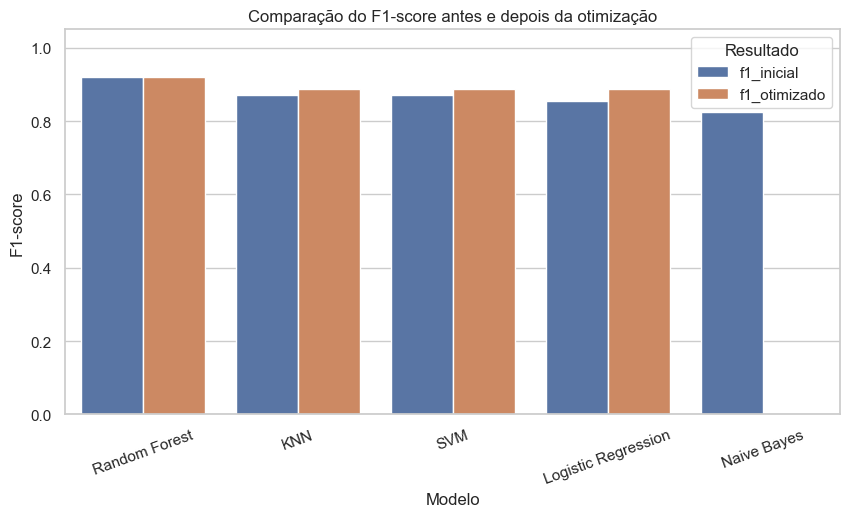

In [ ]:
comparacao_grafico = comparacao_final.melt(
    id_vars='modelo',
    value_vars=['f1_inicial', 'f1_otimizado'],
    var_name='tipo_resultado',
    value_name='f1_score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparacao_grafico, x='modelo', y='f1_score', hue='tipo_resultado')
plt.title('Comparação do F1-score antes e depois da otimização')
plt.xlabel('Modelo')
plt.ylabel('F1-score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title='Resultado')
plt.show()


## 20. Melhor modelo final

Vamos selecionar o modelo com maior F1-score após a otimização e analisar sua matriz de confusão.


Melhor modelo: Random Forest
Melhores parâmetros: {'modelo__max_depth': None, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 300}
Relatório de classificação do melhor modelo:
              precision    recall  f1-score   support

        Kama       0.94      0.81      0.87        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.88      1.00      0.93        21

    accuracy                           0.92        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.92      0.92      0.92        63



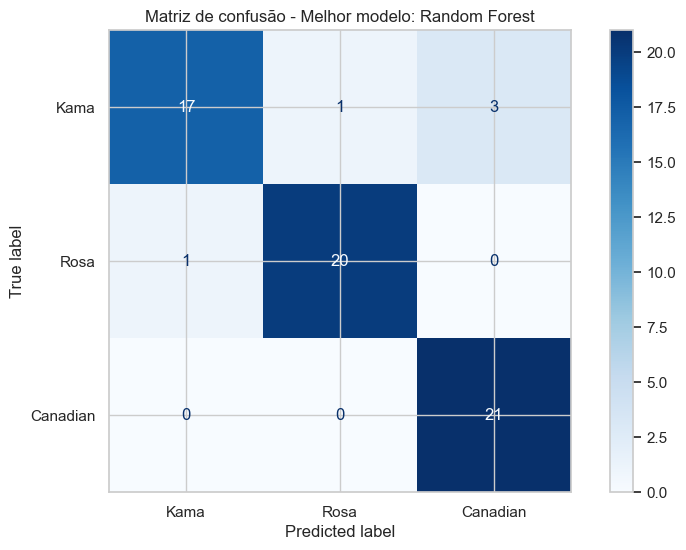

In [ ]:
melhor_linha = resultado_otimizado.iloc[0]
melhor_nome = melhor_linha['modelo']
melhor_modelo = melhores_modelos[melhor_nome]

y_pred_final = melhor_modelo.predict(X_test)

print('Melhor modelo:', melhor_nome)
print('Melhores parâmetros:', melhor_linha['melhores_parametros'])
print('Relatório de classificação do melhor modelo:')
print(classification_report(y_test, y_pred_final, target_names=nomes_classes))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title(f'Matriz de confusão - Melhor modelo: {melhor_nome}')
plt.show()


## 21. Importância das variáveis

Para extrair insights sobre quais características ajudam mais na classificação, podemos usar o Random Forest, pois ele fornece uma estimativa de importância das variáveis.


In [ ]:
rf_insight = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
rf_insight.fit(X_train, y_train)

importancias = pd.DataFrame({
    'caracteristica': features,
    'importancia': rf_insight.feature_importances_
}).sort_values(by='importancia', ascending=False)

importancias


,caracteristica,importancia
0,area,0.220894
1,perimetro,0.213161
4,largura_nucleo,0.167448
6,comprimento_sulco,0.163290
3,comprimento_nucleo,0.117353
5,coef_assimetria,0.065329
2,compacidade,0.052525


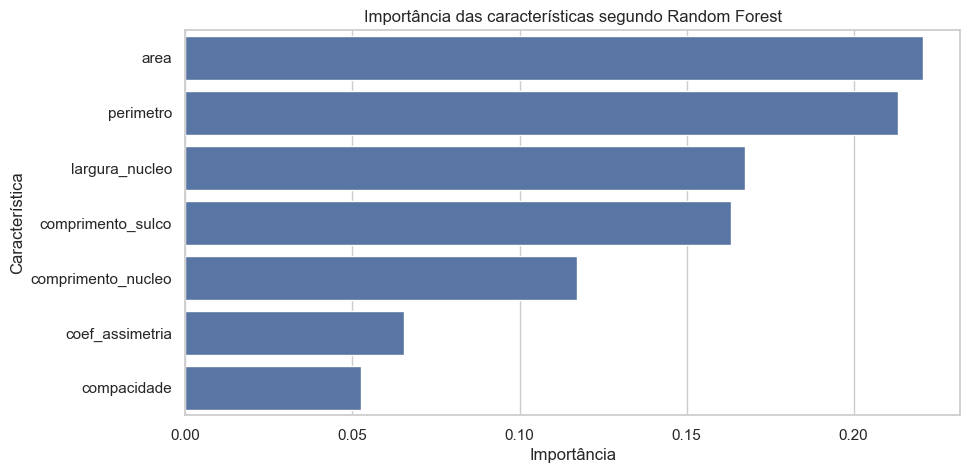

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=importancias, x='importancia', y='caracteristica')
plt.title('Importância das características segundo Random Forest')
plt.xlabel('Importância')
plt.ylabel('Característica')
plt.show()


## 22. Interpretação dos resultados e insights finais

Com base na análise exploratória e nos modelos treinados, podemos concluir:

1. **A base está balanceada**, com 70 amostras para cada variedade de trigo. Isso facilita a comparação entre os modelos e torna a acurácia uma métrica mais útil.

2. **As características físicas dos grãos são relevantes para classificação**, principalmente medidas ligadas ao tamanho e formato, como área, perímetro, largura/comprimento do núcleo e comprimento do sulco.

3. **A escala das variáveis precisa ser considerada**, principalmente para modelos como KNN, SVM e Regressão Logística. Por isso, o uso do `StandardScaler` foi importante.

4. **Os modelos apresentaram bom desempenho geral**, indicando que as variedades Kama, Rosa e Canadian possuem padrões físicos que permitem a classificação automatizada.

5. **Random Forest ajuda na interpretação**, pois permite observar a importância relativa das características. Isso é útil para o contexto agrícola, pois mostra quais medidas físicas mais contribuem para diferenciar os grãos.

6. **A automação pode reduzir tempo e erro humano** em cooperativas agrícolas, tornando a classificação dos grãos mais rápida, padronizada e escalável.

### Conclusão geral

O trabalho demonstrou que é possível aplicar Machine Learning para automatizar a classificação de variedades de grãos de trigo. Seguindo a metodologia CRISP-DM, passamos pelo entendimento do problema, análise dos dados, preparação, modelagem, avaliação e interpretação dos resultados. O melhor modelo pode ser usado como base para um sistema de apoio à decisão em cooperativas agrícolas, desde que validado com dados reais coletados em maior escala.
